# **Preparation**

In [3]:
import pandas as pd

In [ ]:
df = pd.read_parquet('../data/cleaned/ulasan_dana.parquet')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   id_ulasan        150000 non-null  object        
 1   user             150000 non-null  object        
 2   ulasan           150000 non-null  object        
 3   rating           150000 non-null  int64         
 4   dukungan_ulasan  150000 non-null  int64         
 5   tanggal          150000 non-null  datetime64[ns]
 6   versi_aplikasi   150000 non-null  category      
dtypes: category(1), datetime64[ns](1), int64(2), object(3)
memory usage: 7.2+ MB


# **Text Analysis**

Mendeteksi Emoji
---

In [5]:
# %pip install emoji

In [ ]:
import emoji

def has_emoji(text):
    return emoji.emoji_count(str(text)) > 0
df_with_emoji = df[df['ulasan'].apply(has_emoji)]
df_with_emoji['ulasan'].head(5)

39     jelek sekali fitur dana cicil gada mines saldo...
44     kenapa dana saya bermasalah saat login ada tul...
86     setelah update terbaru apk gagal aktif di Sams...
108    kenapa saya tidak bisa meng akses wajah saya s...
114    keamanan nya enggak bgt masa orang lain bisa l...
Name: ulasan, dtype: object

Mendeteksi Campuran Indo-Inggris (Code-Switching)
---

In [ ]:
eng_stopwords = {'the', 'is', 'and', 'not', 'app', 'login', 'error', 'slow', 'service', 'bad'}

def is_mixed_english(text):
    words = set(str(text).lower().split())
    return not words.isdisjoint(eng_stopwords)

df_mixed = df[df['ulasan'].apply(is_mixed_english)]
print(df_mixed['ulasan'].head(10))

7      kurang puas dg cs. slow respon, cs digital, ma...
10     susah amat login keperangkat baru gara² verifi...
16     ini gmna kok login jdi susahh parah lama" unin...
18     TOLONG PIHAK DANA BANTU AKUN SAYA AGAR BISA LO...
43     Saya tida bisa login apa.kndala nya.mohon bant...
44     kenapa dana saya bermasalah saat login ada tul...
71     tidak bisa login keterangan jaringan bermasala...
83     Dana kntl itu verikasi mau kirim nya nyebelin ...
96                                tidak dapat login lagi
106    gada penjelasan sama sekali cuman karna nomor ...
Name: ulasan, dtype: object


Mendeteksi Bahasa Tidak Baku (Slang/Typo)
---

In [8]:
# %pip install PySastrawi

In [ ]:
from Sastrawi.Dictionary.ArrayDictionary import ArrayDictionary
kata_baku = {'aplikasi', 'transaksi', 'saldo', 'saya', 'bisa', 'tidak', 'kecewa', 'bagus', 'mudah', 'puas', 'cepat', 'karena', 'susah' } 

def count_non_baku(text):
    words = str(text).lower().split()
    non_baku = [w for w in words if w not in kata_baku and w.isalpha()]
    return non_baku

In [ ]:
df['slang_words'] = df['ulasan'].apply(count_non_baku)
print(df[['ulasan', 'slang_words']].head(10))

                                              ulasan  \
0  Halo kepada pihak dana, ini kok saya semalam b...   
1  SALDO DANA SAYA MENGHILANG KENAPA DANA SEKARAN...   
2     tidak bisa pindah saldo ketika nomer hp hangus   
3  saya sudah donwload aplikasi ini dan sudah sya...   
4  Membagongkan bisa isi saldo tp G bisa buat ngirim   
5  Dana ngk amanah transaksi Qr dari november sam...   
6  Status Program Beta tidak pernah berubah sudah...   
7  kurang puas dg cs. slow respon, cs digital, ma...   
8  saldo dan saya hilang tiba2 di ambil google ti...   
9  ini gimana ya, waktu beli pulsa ktny lagi di p...   

                                         slang_words  
0  [halo, kepada, pihak, ini, kok, semalam, beli,...  
1  [dana, menghilang, kenapa, dana, sekarang, sep...  
2                [pindah, ketika, nomer, hp, hangus]  
3  [sudah, donwload, ini, dan, sudah, sya, daftar...  
4           [membagongkan, isi, tp, g, buat, ngirim]  
5  [dana, ngk, amanah, qr, dari, november, samapa... 

Melihat 20 kata "non-baku" yang paling sering muncul
---

In [11]:
# %pip install collections

In [ ]:
from collections import Counter

all_words = " ".join(df['ulasan'].astype(str)).lower().split()
word_freq = Counter(all_words)
top_slang = {word: count for word, count in word_freq.items() if word not in kata_baku and len(word) > 2}
print(sorted(top_slang.items(), key=lambda item: item[1], reverse=True)[:100])

[('dana', 62092), ('ada', 22462), ('nya', 19486), ('dan', 16605), ('ini', 16174), ('sangat', 15709), ('gak', 14400), ('kenapa', 14267), ('sudah', 14062), ('mau', 13647), ('tapi', 12610), ('akun', 12445), ('tolong', 12442), ('uang', 10735), ('padahal', 10595), ('masuk', 10124), ('udah', 9551), ('yang', 9137), ('cicil', 8959), ('lagi', 8951), ('apk', 7725), ('untuk', 7509), ('malah', 6851), ('aja', 6690), ('membantu', 6494), ('lama', 6334), ('buat', 5898), ('sekarang', 5829), ('hilang', 5707), ('pake', 5674), ('dari', 5626), ('baik', 5624), ('sering', 5603), ('kok', 5569), ('login', 5550), ('mantap', 5297), ('premium', 5197), ('sama', 5128), ('terus', 5078), ('buka', 5036), ('juga', 4977), ('fitur', 4826), ('update', 4792), ('jadi', 4729), ('masih', 4709), ('harus', 4691), ('belum', 4585), ('makin', 4580), ('banget', 4492), ('nomor', 4186), ('baru', 4166), ('pakai', 4148), ('gimana', 4123), ('selalu', 4111), ('kirim', 4087), ('mohon', 3977), ('itu', 3860), ('perbaiki', 3848), ('transfer'

Top 20 Emoji
---

In [ ]:
import emoji
from collections import Counter
import pandas as pd

def extract_emojis(text):
    return ''.join(c for c in str(text) if emoji.is_emoji(c))

all_emojis_list = df['ulasan'].fillna('').apply(extract_emojis)
all_emojis_str = "".join(all_emojis_list)

emoji_counts = Counter(all_emojis_str)
top_20_emojis = emoji_counts.most_common(50)

print("Top 20 Emojis di Ulasan DANA:")
for emo, count in top_20_emojis:
    print(f"{emo} : {count}")

Top 20 Emojis di Ulasan DANA:
👍 : 3085
🙏 : 2832
😭 : 1375
👎 : 670
🏻 : 644
😡 : 520
🤦 : 360
😔 : 267
🥰 : 209
😁 : 197
🥲 : 179
👌 : 171
😊 : 169
⭐ : 166
😂 : 146
🤣 : 139
😠 : 116
🥺 : 115
🤔 : 111
😇 : 111
🌟 : 111
🙂 : 109
😘 : 109
😢 : 104
😒 : 100
😍 : 100
😤 : 98
😌 : 95
🤬 : 93
🙄 : 92
🗿 : 90
❤ : 88
😩 : 85
🏼 : 83
😞 : 80
☺ : 79
😥 : 78
♂ : 78
😑 : 77
😅 : 71
😀 : 62
🔥 : 61
🥴 : 60
😎 : 59
💯 : 59
😓 : 58
🤩 : 54
😏 : 51
😮 : 51
💨 : 51


Mencari Ulasan "Hanya Emoji"
---

In [ ]:
import emoji
import pandas as pd

def is_only_emoji(text):
    text = str(text).strip()
    if not text:
        return False
    only_emojis = "".join(c for c in text if emoji.is_emoji(c))
    return len(only_emojis) == len(text.replace(" ", ""))

df_only_emoji = df[df['ulasan'].apply(is_only_emoji)]

total_only_emoji = len(df_only_emoji)
persentase = (total_only_emoji / len(df)) * 100

print(f"Jumlah ulasan hanya emoji: {total_only_emoji} baris")
print(f"Persentase dari total data: {persentase:.2f}%")

Jumlah ulasan hanya emoji: 902 baris
Persentase dari total data: 0.60%


In [ ]:
print("\nContoh ulasan hanya emoji:")
df_only_emoji[['ulasan', 'rating']].head(20)


Contoh ulasan hanya emoji:
         ulasan  rating
358           👍       1
724     👎👎👎👎👎👎👎       1
6127        👍👍👍       1
7822          🙂       1
7978          😇       1
9693   👎🏻👎🏻👎🏻👎🏻       1
9818          👍       1
10342         👍       1
11647        😘👍       1
12406    👎👎👎👎👎👎       1
13389        🙃🙃       1
19749         👎       1
19899         👎       1
22282         👍       1
23511         😀       1
24113       💩💩💩       1
26041      🔥🔥🔥🔥       2
26173         🤩       2
27022        👿👿       2
27738        👍👍       2


In [ ]:
import emoji
def check_emoji_only(text):
    text = str(text).replace(" ", "")
    if not text or text == "no review":
        return False
    return all(char in emoji.EMOJI_DATA for char in text)

df['is_emoji_only'] = df['ulasan'].apply(check_emoji_only)

print("Kolom 'is_emoji_only' berhasil dibuat.")
print(df['is_emoji_only'].value_counts())

Kolom 'is_emoji_only' berhasil dibuat.
is_emoji_only
False    149098
True        902
Name: count, dtype: int64


In [ ]:
from collections import Counter

df_emoji_only = df[df['is_emoji_only'] == True]
all_emojis = "".join(df_emoji_only['ulasan'].astype(str))
emoji_list = [c for c in all_emojis if c in emoji.EMOJI_DATA]
emoji_counts = Counter(emoji_list)
print("Top 10 Emoji yang hanya berisi emoji:")
for emo, freq in emoji_counts.most_common(7206):
    print(f"{emo} : {freq} kali")

Top 10 Emoji yang hanya berisi emoji:
👍 : 1192 kali
🏻 : 80 kali
👌 : 62 kali
🥰 : 41 kali
😍 : 39 kali
🙏 : 38 kali
😠 : 30 kali
😁 : 26 kali
👎 : 21 kali
⭐ : 21 kali
😊 : 18 kali
💯 : 15 kali
😡 : 13 kali
🔥 : 12 kali
😇 : 11 kali
🤗 : 10 kali
😀 : 9 kali
🤩 : 9 kali
😎 : 9 kali
🙂 : 8 kali
😘 : 8 kali
🌟 : 7 kali
🌧 : 6 kali
🏽 : 6 kali
😴 : 5 kali
🤬 : 5 kali
🏿 : 5 kali
🏼 : 5 kali
🌹 : 5 kali
👿 : 4 kali
😢 : 4 kali
🗿 : 4 kali
🆗 : 4 kali
☺ : 4 kali
😃 : 4 kali
😭 : 4 kali
👆 : 4 kali
🤲 : 4 kali
🥲 : 4 kali
😄 : 4 kali
🙄 : 4 kali
💩 : 3 kali
🥳 : 3 kali
🫰 : 3 kali
🖤 : 3 kali
😳 : 3 kali
🤟 : 3 kali
😅 : 3 kali
🤔 : 3 kali
🥉 : 3 kali
🤝 : 3 kali
👏 : 3 kali
🙃 : 2 kali
🧐 : 2 kali
🤦 : 2 kali
🏾 : 2 kali
🥵 : 2 kali
❤ : 2 kali
🤘 : 2 kali
🤭 : 2 kali
😂 : 2 kali
👊 : 2 kali
😶 : 1 kali
😐 : 1 kali
🐭 : 1 kali
🏧 : 1 kali
😤 : 1 kali
💜 : 1 kali
💞 : 1 kali
😜 : 1 kali
👮 : 1 kali
😒 : 1 kali
🤫 : 1 kali
😕 : 1 kali
😈 : 1 kali
😏 : 1 kali
🐍 : 1 kali
📼 : 1 kali
📠 : 1 kali
🤑 : 1 kali
😔 : 1 kali
🖐 : 1 kali
🤚 : 1 kali
💪 : 1 kali
🥶 : 1 kali
💢 : 1 kal

In [ ]:
from collections import Counter
import emoji

all_text = "".join(df_only_emoji['ulasan'].astype(str))
emojis_found = [c for c in all_text if c in emoji.EMOJI_DATA]
top_emojis = Counter(emojis_found).most_common(20)

print("Daftar Emoji yang perlu ditransformasi:")
for emo, count in top_emojis:
    print(f"{emo} : muncul {count} kali ({emoji.demojize(emo)})")

Daftar Emoji yang perlu ditransformasi:
👍 : muncul 1192 kali (:thumbs_up:)
🏻 : muncul 80 kali (:light_skin_tone:)
👌 : muncul 62 kali (:OK_hand:)
🥰 : muncul 41 kali (:smiling_face_with_hearts:)
😍 : muncul 39 kali (:smiling_face_with_heart-eyes:)
🙏 : muncul 38 kali (:folded_hands:)
😠 : muncul 30 kali (:angry_face:)
😁 : muncul 26 kali (:beaming_face_with_smiling_eyes:)
👎 : muncul 21 kali (:thumbs_down:)
⭐ : muncul 21 kali (:star:)
😊 : muncul 18 kali (:smiling_face_with_smiling_eyes:)
💯 : muncul 15 kali (:hundred_points:)
😡 : muncul 13 kali (:enraged_face:)
🔥 : muncul 12 kali (:fire:)
😇 : muncul 11 kali (:smiling_face_with_halo:)
🤗 : muncul 10 kali (:smiling_face_with_open_hands:)
😀 : muncul 9 kali (:grinning_face:)
🤩 : muncul 9 kali (:star-struck:)
😎 : muncul 9 kali (:smiling_face_with_sunglasses:)
🙂 : muncul 8 kali (:slightly_smiling_face:)


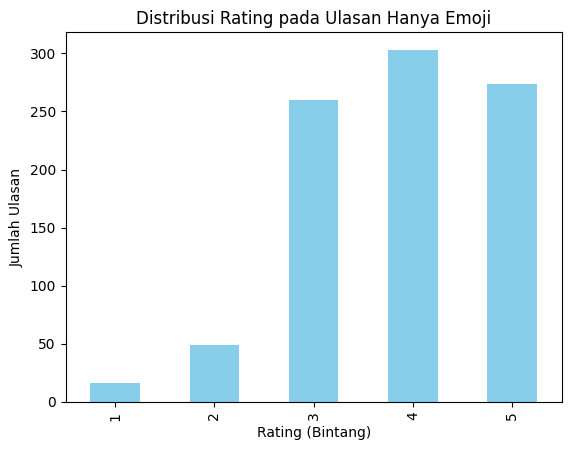

In [ ]:
import matplotlib.pyplot as plt

df_only_emoji['rating'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Distribusi Rating pada Ulasan Hanya Emoji')
plt.xlabel('Rating (Bintang)')
plt.ylabel('Jumlah Ulasan')
plt.show()

In [ ]:
import plotly.express as px
import plotly.graph_objects as go

counts = df_only_emoji['rating'].value_counts().sort_index().reset_index()
counts.columns = ['Rating', 'Jumlah']
total_emoji = counts['Jumlah'].sum()
counts['Persentase'] = (counts['Jumlah'] / total_emoji * 100).round(2)
fig = px.bar(
    counts, 
    x='Rating', 
    y='Jumlah',
    text=counts.apply(lambda r: f"{r['Jumlah']}<br>({r['Persentase']}%)", axis=1), # Label di atas batang
    color='Jumlah',
    color_continuous_scale='Blues',
    title='<b>Distribusi Rating: Ulasan Hanya Emoji</b>',
    labels={'Rating': 'Rating (Bintang)', 'Jumlah': 'Total Ulasan'},
    template='plotly_white'
)

fig.update_traces(
    textposition='outside',
    marker_line_color='rgb(8,48,107)', 
    marker_line_width=1.5, 
    opacity=0.8
)

fig.update_layout(
    xaxis=dict(tickmode='linear'),
    yaxis_title="Jumlah Ulasan",
    font=dict(family="Arial", size=12),
    margin=dict(l=50, r=50, t=80, b=50),
    showlegend=False
)

fig.show()

# **Text Processing**

Tahap Pembersihan (Cleaning)
----

In [ ]:
import re
import emoji

def cleaning_pipeline(text):
    if not isinstance(text, str): return ""
    
    # 1. Ubah ke huruf kecil
    text = text.lower()
    # 2. Hapus URL/Link
    text = re.sub(r'http\S+|www\S+|@\S+|#\S+', '', text)
    # 3. Hapus angka dan karakter spesial (kecuali spasi)
    # Catatan: Kita hapus ini SETELAH penanganan emoji (opsional) atau biarkan huruf saja
    text = re.sub(r'[^a-z\s]', ' ', text)
    # 4. Hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Gunakan progress_apply agar kamu bisa memantau proses 1 juta data
from tqdm import tqdm
tqdm.pandas()

print("Sedang melakukan cleaning...")
df['content_cleaned'] = df['ulasan'].progress_apply(cleaning_pipeline)

Sedang melakukan cleaning...


KeyError: 'content'

In [ ]:
df.head(10)

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,slang_words,content_cleaned
0,8c382ad2-2c81-436e-a18e-87be3fdcc662,Hermansyah Radin,https://play-lh.googleusercontent.com/a/ACg8oc...,ok,5,0,NaN,2026-01-22 09:14:57,NaN,NaN,NaN,[ok],ok
1,47553db5-9026-4233-8bf7-8449e550da69,Zidni Cell,https://play-lh.googleusercontent.com/a-/ALV-U...,bagus,5,0,NaN,2026-01-22 09:11:52,NaN,NaN,NaN,[bagus],bagus
2,9a1a84ba-1b7d-4010-a58d-1f373b280082,Akhi Sondi,https://play-lh.googleusercontent.com/a-/ALV-U...,mantulll pokok eh,5,0,2.110.0,2026-01-22 09:11:39,NaN,NaN,2.110.0,"[mantulll, pokok, eh]",mantulll pokok eh
3,0460a39e-7580-44bf-8a79-8446fb2414eb,Yati Yati,https://play-lh.googleusercontent.com/a/ACg8oc...,mempermudah,5,0,2.110.0,2026-01-22 09:09:57,NaN,NaN,2.110.0,[mempermudah],mempermudah
4,b461e228-9033-4bea-b835-322d0db38fc2,Joker 16,https://play-lh.googleusercontent.com/a/ACg8oc...,mantap,5,0,2.111.0,2026-01-22 09:09:34,NaN,NaN,2.111.0,[mantap],mantap
5,3f0e59e5-d9c1-4f94-947b-e8ac096fb1db,Noe Aink,https://play-lh.googleusercontent.com/a-/ALV-U...,setelah di update malah gak bisa dibuka/fc mul...,3,0,2.111.0,2026-01-22 09:07:21,NaN,NaN,2.111.0,"[setelah, di, update, malah, gak, sudah, hapus...",setelah di update malah gak bisa dibuka fc mul...
6,e4617d28-61f4-4e34-9a72-20613e8c8dc5,Mutia Adisty,https://play-lh.googleusercontent.com/a/ACg8oc...,puas,5,0,2.111.0,2026-01-22 09:04:44,NaN,NaN,2.111.0,[puas],puas
7,7e3d8ff6-448b-408a-8891-01ad7baf45e8,Redmi Series,https://play-lh.googleusercontent.com/a/ACg8oc...,kenapa susah verifikasi wajah ya,5,0,2.111.0,2026-01-22 09:03:29,NaN,NaN,2.111.0,"[kenapa, susah, verifikasi, wajah, ya]",kenapa susah verifikasi wajah ya
8,16ed083e-bb68-472a-82cd-fe871d702ad4,Yana Mulyana,https://play-lh.googleusercontent.com/a/ACg8oc...,keren cepat pengiriman uang nya,5,0,2.111.0,2026-01-22 09:03:00,NaN,NaN,2.111.0,"[keren, cepat, pengiriman, uang, nya]",keren cepat pengiriman uang nya
9,f0f79437-2efe-4574-99b2-0f3fb28df85b,aspar konami98,https://play-lh.googleusercontent.com/a-/ALV-U...,sangat memuaskan pake aplikasi dana,5,0,NaN,2026-01-22 09:00:42,NaN,NaN,NaN,"[sangat, memuaskan, pake, dana]",sangat memuaskan pake aplikasi dana


Tahap Normalisasi (Slang Removal)
---

Load Data & Filter Emoji
---

In [ ]:
import emoji

# Fungsi deteksi emoji only (sebagai filter terakhir)
def is_emoji_only(text):
    text = str(text).replace(" ", "")
    if not text or text == "no review":
        return False
    return all(char in emoji.EMOJI_DATA for char in text)

# Filter: Ambil yang BUKAN emoji only
df = df[~df['ulasan'].apply(is_emoji_only)].copy()

# Reset index agar tidak ada nomor baris yang lompat
df.reset_index(drop=True, inplace=True)

print(f"Data siap diolah: {len(df)} baris.")

Data siap diolah: 665794 baris.


In [ ]:
import re

# Load data (Asumsi df sudah berisi data dari ulasan_dana_cleaned.parquet)

def text_preprocessing_final(text):
    # 1. Menghapus Emoji (replace_emoji lebih cepat untuk ulasan panjang)
    text = emoji.replace_emoji(str(text), replace='')
    
    # 2. Case Folding (Mengubah ke huruf kecil)
    text = text.lower()
    
    # 3. Cleaning: Menghapus URL, Angka, dan Tanda Baca
    text = re.sub(r'http\S+|www\S+|@\S+', '', text) # Link/URL
    text = re.sub(r'[^a-z\s]', ' ', text)           # Sisakan hanya huruf a-z
    
    # 4. Menghapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Eksekusi pada dataset
print("Memulai pembersihan teks...")
df['ulasan_processed'] = df['ulasan'].apply(text_preprocessing_final)

# Drop baris yang ternyata kosong setelah dibersihkan (misal ulasan hanya simbol '!!!')
# df = df[df['ulasan_processed'] != ""].copy()
# df.reset_index(drop=True, inplace=True)

print(f"Pembersihan selesai. Total data aktif: {len(df)} baris.")

Memulai pembersihan teks...
Pembersihan selesai. Total data aktif: 665794 baris.
